In [1]:
import sys
sys.path.append("/Users/chris/Documents/higs-vision")
import optuna
import torch
import numpy as np
import time
import json

from src.data import load_config, load_processed
from src.models import HiggsDNN
from src.train import train, save_training_run

optuna.logging.set_verbosity(optuna.logging.WARNING)

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)


In [2]:
def objective(trial):
    # Suggest hyperparameters
    width = trial.suggest_categorical("hidden_width", [256, 512, 1024])
    hidden_dims = [width, width // 2, width // 4, width // 8]
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    activation = trial.suggest_categorical("activation", ["ReLU", "GELU", "SiLU"])
    use_batch_norm = trial.suggest_categorical("batch_norm", [True, False])
    lr = trial.suggest_float("learning_rate", 5e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [1024, 2048, 4096, 8192])
    cosine = trial.suggest_categorical("cosine_annealing", [True, False])

    # Create model
    model = HiggsDNN(
        input_dim=config["dataset"]["n_features"],
        hidden_dims=hidden_dims,
        activation=activation,
        dropout_rate=dropout_rate,
        use_batch_norm=use_batch_norm
    )

    # Override config with trial suggestions
    trial_config = json.loads(json.dumps(config))  # deep copy
    trial_config["dnn"]["learning_rate"] = lr
    trial_config["dnn"]["weight_decay"] = weight_decay
    trial_config["dnn"]["batch_size"] = batch_size
    trial_config["dnn"]["cosine_annealing"] = cosine
    trial_config["dnn"]["max_epochs"] = 40  # fewer epochs during search
    trial_config["dnn"]["early_stopping_patience"] = 8

    # Train and get history
    model, history = train(
        model, X_train, y_train, X_val, y_val,
        trial_config, seed=config["seeds"]["optuna_sampler"],
        trial=trial
    )

    best_auc = max(history["val_auc"])
    return best_auc

In [3]:
import os
os.makedirs("/Users/chris/Documents/higs-vision/results/optuna", exist_ok=True)

In [4]:
study = optuna.create_study(
    study_name=config["optuna"]["study_name"],
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=config["seeds"]["optuna_sampler"]),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    storage="sqlite:////Users/chris/Documents/higs-vision/results/optuna/higgs_hpo.db",
    load_if_exists=True
)

print(f"Starting Optuna HPO study")
print(f"Time budget: {config['optuna']['time_budget_hours']} hours")
print(f"Pruner: MedianPruner (startup=5, warmup=5 epochs)")
print()

start_time = time.time()
study.optimize(
    objective,
    timeout=3600,  # 1 hour
    show_progress_bar=True
)
total_time = time.time() - start_time

print(f"\nStudy completed in {total_time/3600:.1f} hours")
print(f"Total trials: {len(study.trials)}")
print(f"Completed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print(f"Best trial: #{study.best_trial.number}")
print(f"Best validation AUC: {study.best_value:.4f}")

Starting Optuna HPO study
Time budget: 24 hours
Pruner: MedianPruner (startup=5, warmup=5 epochs)



   0%|          | 00:00/1:00:00

Epoch   1 | Train Loss: 0.5734 | Val Loss: 0.5358 | Val AUC: 0.8056 | Time: 14.5s
Epoch   2 | Train Loss: 0.5408 | Val Loss: 0.5218 | Val AUC: 0.8155 | Time: 13.4s
Epoch   3 | Train Loss: 0.5318 | Val Loss: 0.5149 | Val AUC: 0.8216 | Time: 13.6s
Epoch   4 | Train Loss: 0.5257 | Val Loss: 0.5092 | Val AUC: 0.8257 | Time: 13.5s
Epoch   5 | Train Loss: 0.5221 | Val Loss: 0.5059 | Val AUC: 0.8285 | Time: 13.3s
Epoch   6 | Train Loss: 0.5189 | Val Loss: 0.5020 | Val AUC: 0.8311 | Time: 13.1s
Epoch   7 | Train Loss: 0.5168 | Val Loss: 0.5017 | Val AUC: 0.8316 | Time: 13.3s
Epoch   1 | Train Loss: 0.6352 | Val Loss: 0.6015 | Val AUC: 0.7371 | Time: 9.3s
Epoch   2 | Train Loss: 0.5980 | Val Loss: 0.5725 | Val AUC: 0.7686 | Time: 9.4s
Epoch   3 | Train Loss: 0.5783 | Val Loss: 0.5571 | Val AUC: 0.7841 | Time: 9.3s
Epoch   4 | Train Loss: 0.5677 | Val Loss: 0.5484 | Val AUC: 0.7921 | Time: 9.1s
Epoch   5 | Train Loss: 0.5611 | Val Loss: 0.5428 | Val AUC: 0.7974 | Time: 9.1s
Epoch   1 | Train Los

In [5]:
print("=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"\nBest validation AUC: {study.best_value:.4f}")

BEST HYPERPARAMETERS
  hidden_width: 1024
  dropout: 0.41232909472546486
  activation: GELU
  batch_norm: False
  learning_rate: 0.001224255047922116
  weight_decay: 0.00034159620263479035
  batch_size: 2048
  cosine_annealing: True

Best validation AUC: 0.8483


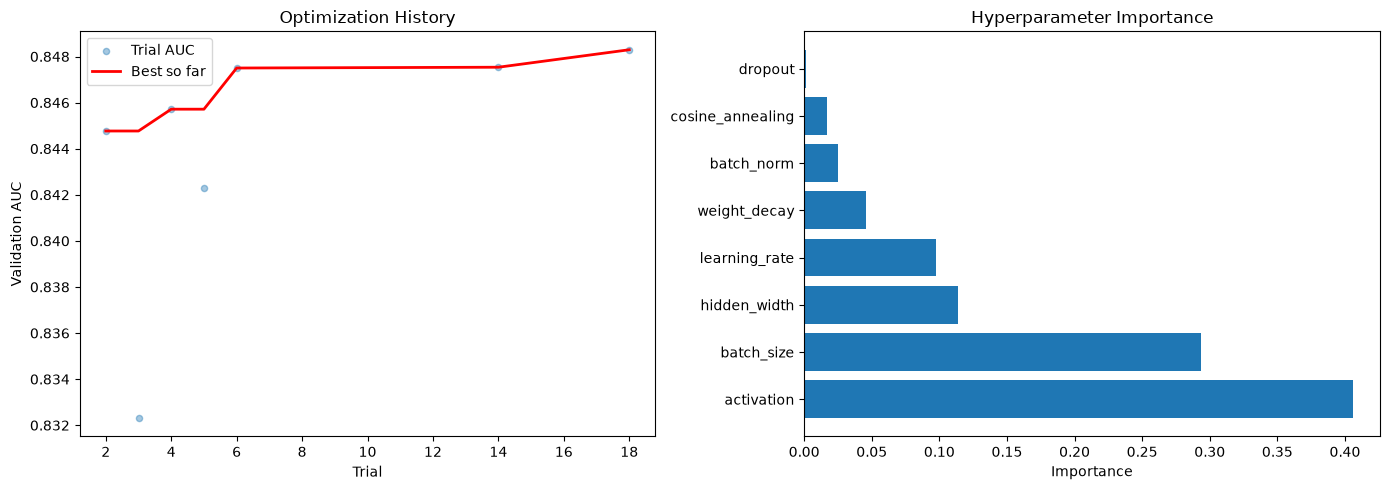

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in trials]
trial_aucs = [t.value for t in trials]
best_so_far = np.maximum.accumulate(trial_aucs)

axes[0].scatter(trial_nums, trial_aucs, alpha=0.4, s=20, label="Trial AUC")
axes[0].plot(trial_nums, best_so_far, color="red", linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation AUC")
axes[0].set_title("Optimization History")
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
params = list(importances.keys())
values = list(importances.values())
axes[1].barh(params, values)
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter Importance")

plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/optuna_history.png", dpi=150)
plt.show()

In [7]:
best_params = study.best_params.copy()
best_params["best_val_auc"] = study.best_value
best_params["n_trials"] = len(study.trials)
best_params["total_time_hours"] = total_time / 3600

import json
with open("/Users/chris/Documents/higs-vision/results/optuna/best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

print("Best parameters saved to results/optuna/best_params.json")

Best parameters saved to results/optuna/best_params.json
